In [35]:
! pip install pycountry
! pip install country_converter

In [36]:
import pandas as pd
import re
#! pip install pycountry
import pycountry
import seaborn as sns
#! pip install country_converter
import country_converter as coco
import matplotlib.pyplot as plt

sd_df=pd.read_excel("https://www.sharkattackfile.net/spreadsheets/GSAF5.xls")

In [37]:
def clean_col_date(df):
  df2=df.copy()

  #clean date string
  df2["Date"] = (
    df2["Date"]
    .astype("string")
    .str.title()
    .str.strip()
    # remove space around "-""
    .str.replace(
        r'\s*-\s*',
        '-',
        regex=True
    )
    # keep only one "-"
    .str.replace(
    r'-+',
    '-',
    regex=True
    )
    # remove upfront words befor date
    .str.replace(
        r'^(Reported|Updated|Dated|Letter dated)\s+',
        '',
        regex=True
    )
    # replace separator
    .str.replace(
        r'(?<=[A-Za-z])-(?=\d)',
        ' ',
        regex=True
    )
    .str.replace(
        r'(?<=\d)-(?=[A-Za-z])',
        ' ',
        regex=True
    )
     # combine spaces
    .str.replace(
        r'\s+',
        ' ',
        regex=True
    )
  )
  #conver month
  month_map = {
      "January": "Jan",
      "February": "Feb",
      "March": "Mar",
      "April": "Apr",
      "June": "Jun",
      "July": "Jul",
      "August": "Aug",
      "September": "Sep",
      "Sept": "Sep",
      "October":"Oct",
      "November":"Nov",
      "December":"Dec"
  }
  for full, short in month_map.items():
      df2["Date"] = (
          df2["Date"]
          .str.replace(
              full,
              short,
              regex=False
          )
      )
  # clean Year columne
  df2["Year"] = (
      df2["Year"]
      .astype("Int64")
      .astype("string")
  )
  # date type classification
  conditions = [
      # datetime_string ^\d{4}\s+\d{2}\s+\d{2}\s+\d{2}:\d{2}:\d{2}$
      df2["Date"].str.match(
          r'^\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}:\d{2}$',
          na=False
      ),
      # english_full_date
      df2["Date"].str.match(
          r'^\d{1,2}\s+[A-Za-z]{3}\s+\d{4}$',
          na=False
      ),
      # english_day_month
      df2["Date"].str.match(
          r'^\d{1,2}(st|nd|rd|th)?\s+[A-Za-z]+$',
          case=False,
          na=False
      ),

      # seasonal_date
      df2["Date"].str.match(
          r'^(Spring|Summer|Fall|Autumn|Winter)\s+\d{4}$',
          case=False,
          na=False
      ),
      # approximate_date
      df2["Date"].str.match(
          r'^(Late|Early|Mid)\s+[A-Za-z]{3}-\d{4}$',
          case=False,
          na=False
      ),
      # approximate_year
      df2["Date"].str.match(
          r'^(Early|Mid|Late)\s+\d{4}$',
          case=False,
          na=False
      ),
      # circa_date
      df2["Date"].str.match(
          r'^(Circa|Approx\.?|Around)\s+\d{4}$',
          case=False,
          na=False
      ),
      # before_after
      df2["Date"].str.match(
          r'^(Before|After)\s+\d{4}$',
          case=False,
          na=False
      ),

      # month_year
      df2["Date"].str.match(
          r'^[A-Za-z]+\s+\d{4}$',
          na=False
      ),
      # year_only
      df2["Date"].str.match(
          r'^\d{4}$',
          na=False
      )

  ]

  choices = [
      "datetime_string",
      "english_full_date",
      "english_day_month",

      "seasonal_date",
      "approximate_date",
      "approximate_year",
      "circa_date",
      "before_after",

      "month_year",
      "year_only",
  ]

  df2["date_type"] = np.select(
      conditions,
      choices,
      default="invalid"
  )

  # deal with datetime_string
  df2.loc[df2["date_type"] == "datetime_string","clean_date"] = pd.to_datetime(
      df2.loc[df2["date_type"]== "datetime_string", "Date"],
      format="%Y-%m-%d %H:%M:%S",
      errors="coerce"
  )
  # deal with english_full_date
  df2.loc[df2["date_type"]== "english_full_date","clean_date"]=pd.to_datetime(
      df2.loc[df2["date_type"]== "english_full_date", "Date"],
      format="%d %b %Y",
      errors="coerce"
  )
  # deal with month_year, set day as 1
  temp = ("1 "+ df2.loc[df2["date_type"] == "month_year","Date"])
  df2.loc[df2["date_type"] == "month_year","clean_date"] = pd.to_datetime(
      temp,
      format="%d %b %Y",
      errors="coerce"
  )
  # deal with english_day_month
  temp = (
      df2.loc[df2["date_type"] == "english_day_month","Date"]
      .str.replace(
          r'(\d+)(st|nd|rd|th)',
          r'\1',
          regex=True
      )
  )
  temp = (
      temp
      + " "
      + df2.loc[df2["date_type"] == "english_day_month","Year"]
  )

  df2.loc[df2["date_type"] == "english_day_month","clean_date"] = pd.to_datetime(
      temp,
      format="%d %b %Y",
      errors="coerce"
  )
  # deal with year_only
  # set day month as 01-01
  temp = (df2.loc[df2["date_type"] == "year_only","Date"]+ "-01-01")
  df2.loc[df2["date_type"] == "year_only","clean_date"] = pd.to_datetime(
      temp,
      format="%Y-%m-%d",
      errors="coerce"
  )

  df2["Date"]=df2["clean_date"]
  df2=df2.drop(columns=["clean_date"])
  df2=df2.drop(columns=["date_type"])

  return df2

Cleaning

In [38]:
def clean_col_names(df):
    df2 = df.copy()
    df2.columns = df2.columns.map(lambda x: x.lower().replace(' ','_'))
    return df2

def clean_df(df):
    df2=df.copy()
    df2 = df2.map(lambda x:x.lower().strip() if isinstance(x,str) else x)
    df2 = df2.dropna(how='all')
    df2 = df2.drop_duplicates()
    df2.drop(columns=["pdf"], inplace = True)
    df2.drop(columns=["href_formula"], inplace = True)
    df2.drop(columns=["href"], inplace = True)
    df2.drop(columns=["case_number"], inplace = True)
    df2.drop(columns=["case_number.1"], inplace = True)
    df2.drop(columns=["original_order"], inplace = True)
    df2.drop(columns=["unnamed:_21"], inplace = True)
    df2.drop(columns=["unnamed:_22"], inplace = True)
    return df2

def clean_col_3_type(df):
    """
    replace any attack where the type is not defined with unknown
    """
    df2 = df.copy()
    df2.type = df2.type.map(lambda x:'other' if x not in ['unprovoked','provoked','watercraft'] else x)
    return df2

def clean_col_4_country(df):
    """

    """
    df2 = df.copy()
    countries_list = [country.name.lower() for country in pycountry.countries]
    df2.country = df2.country.replace({'usa':'united states',
                                       'okinawa':'japan','reunion':'réunion','reunion island':'réunion',
                                       'us virgin islands':'virgin islands, u.s.','?':'',
                                       "england": "united kingdom", "scotland": "united kingdom","usa": "united states","us":
                                       "united states","u.s.a": "united states","u.s.": "united states","columbia": "colombia",
                                       "bahrein": "bahrain","ceylon": "sri lanka","ceylon (sri lanka)": "sri lanka",
                                       "burma": "myanmar","cape verde": "cabo verde","san domingo": "dominican republic",
                                       "trinidad": "trinidad and tobago","tobago": "trinidad and tobago",
                                       "trinidad & tobago": "trinidad and tobago", "curacao": "curaçao","korea": "south korea"})
    missing = [i for i in list(df2.country) if i not in countries_list]
    df2['country'] = df2['country'].apply(lambda x: x.upper() if x in countries_list else 'other')
    #missing = [i for i in list(df2.country) if i not in countries_list]
    #display(df2.country.value_counts().head(20))
    #print(set(missing))
    return df2

def clean_col_activity(df):
    """
    use regex to find entries with surf and board
    use regex to find entries with fishing
    """
    df2 = df.copy()
    no_board_pattern = r'\b(swim(ming)?|bathing|snorkel(ing)?)\b'
    fishing_pattern = r'\b\w*fishing\b'
    board_pattern = r'board|surf'
    diving_pattern = r'\b(div(e|ing)?|scuba)\b'
    #re.sub('Boarding',board_pattern,df2.activity)
    # df2.activity = df2.activity.str.replace(board_pattern, 'boarding', regex=True)
    # df2.activity = df2.activity.str.replace(no_board_pattern, 'swimming', regex=True)
    df2.loc[df2.activity.str.contains(r'sunbathing', case=False, na=False),'activity'] = 'other'
    df2.loc[df2.activity.str.contains(board_pattern, case=False, na=False),'activity'] = 'boarding'
    df2.loc[df2.activity.str.contains(no_board_pattern, case=False, na=False),'activity'] = 'swimming'
    df2.loc[df2.activity.str.contains(fishing_pattern, case=False, na=False),'activity'] = 'fishing'
    df2.loc[df2.activity.str.contains(diving_pattern, case=False, na=False),'activity'] = 'diving'
    #display(df2.activity.value_counts())
    return df2

def clean_col_sex(df):
    df2 = df.copy()
    df2.sex = df2.sex.replace({'m x 2':'m','lli':'m','n':'m','?':'unknown','.':'unknown'}) #visual inspection
    df2.sex = df2.sex.apply(lambda x: x.upper() if x in ['m','f'] else 'unknown')
    # display(df2.sex.unique())
    # display(df2.sex.nunique)
    return df2

def clean_col_age(df):
    df2 = df.copy()
    df2.age = df2.age.replace({'!':''})
    df2.age = df2.age.str.replace(r'.*month.*','0',regex=True)
    pattern = r'.*?(\d+).*' #r'(\d+).*'
    df2.age = df2.age.str.replace(pattern,r'\1', regex=True)
    df2.age = df2.age.apply(lambda x: int(x) if str(x).isdigit() else 'unknown')
    # display(df2.age.value_counts())
    # display(df2.head(20))
    return df2

def clean_all(df):
    df2 = df.copy()
    df2 = clean_col_names(df2)
    df2 = clean_df(df2)
    df2 = clean_col_3_type(df2)
    df2 = clean_col_activity(df2)
    df2 = clean_col_4_country(df2)
    df2 = clean_col_sex(df2)
    df2 = clean_col_age(df2)
    df2 = clean_col_date(df2)
    return df2

# def filter_for_recent_attacks(df):
#     df2 = df.copy()
#     df2.loc[df2['year']>=1990]
#     return df2

df3 = clean_all(sd_df)

C:\Users\clair\AppData\Local\Temp\ipykernel_12632\1662613188.py:66: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df2.loc[df2.activity.str.contains(no_board_pattern, case=False, na=False),'activity'] = 'swimming'
C:\Users\clair\AppData\Local\Temp\ipykernel_12632\1662613188.py:68: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df2.loc[df2.activity.str.contains(diving_pattern, case=False, na=False),'activity'] = 'diving'


KeyError: 'Date'

Data Preparation and Exploratory Data Analysis

In [39]:
display(df3.activity.value_counts().head(10))
display(df3[df3['country'] != 'other']['country'].value_counts().head(10))
display(df3[df3['sex'].isin(['M', 'F'])]['sex'].value_counts())

df4 = df3.dropna(subset=['age', 'sex'])
df4 = df4[df4['sex'].isin(['M', 'F'])]
df4 = df4[df4['age']!='unknown']
display(df4.groupby('sex')['age'].agg(['count', 'mean', 'std']))

df5 = df3.dropna(subset=['activity', 'sex'])
df5 = df5[df5['sex'].isin(['M', 'F'])]
top_activity = list(df5.activity.value_counts().head(5).index)
df5 = df5[df5['activity'].isin(top_activity)]
# df5 = df5.grved"]).agg({"Survived": 'count'})
df5_grouped = df5.groupby(["sex","activity"]).agg({"activity": 'count'})
display(df5_grouped)
df5_grouped.groupby(["sex"]).agg({"activity": 'count'})
display(df5_grouped.groupby(level=0, group_keys=False).apply(lambda x:round(100 * x / float(x.sum()),2)))

df6 = df3.dropna(subset=['activity', 'country'])
top_country = list(df5[df5['country']!='other'].country.value_counts().head(10).index)
df6 = df6[df6['country'].isin(top_country)]
top_activity = list(df6.activity.value_counts().head(5).index)
df6 = df6[df6['activity'].isin(top_activity)]
# df5 = df5.grved"]).agg({"Survived": 'count'})
df6_grouped = df6.groupby(["country","activity"]).agg({"activity": 'count'})
display(df6_grouped)
df6_grouped.groupby(["country"]).agg({"activity": 'count'})
display(df6_grouped.groupby(level=0, group_keys=False).apply(lambda x:round(100 * x / float(x.sum()),2)))



activity
boarding          1802
swimming          1577
fishing           1244
diving             545
wading             178
standing           115
kayaking            43
treading water      33
floating            18
walking             17
Name: count, dtype: int64

country
UNITED STATES       2580
AUSTRALIA           1529
SOUTH AFRICA         599
NEW ZEALAND          146
BAHAMAS              142
PAPUA NEW GUINEA     136
BRAZIL               123
MEXICO               107
ITALY                 72
FIJI                  70
Name: count, dtype: int64

sex
M    5693
F     813
Name: count, dtype: int64

,count,mean,std
sex,,,
F,311,27.363344,16.975309
M,1645,28.37386,14.277726


activity
sex activity          
F   boarding       148
    diving          36
    fishing         24
    swimming       327
    wading          70
M   boarding      1611
    diving         488
    fishing       1048
    swimming      1212
    wading         105

C:\Users\clair\AppData\Local\Temp\ipykernel_12632\3937914291.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  display(df5_grouped.groupby(level=0, group_keys=False).apply(lambda x:round(100 * x / float(x.sum()),2)))


activity
sex activity          
F   boarding     24.46
    diving        5.95
    fishing       3.97
    swimming     54.05
    wading       11.57
M   boarding     36.09
    diving       10.93
    fishing      23.48
    swimming     27.15
    wading        2.35

activity
country          activity          
AUSTRALIA        boarding       376
                 diving         156
                 fishing        285
                 swimming       346
                 wading          18
BAHAMAS          boarding         8
                 diving          22
                 fishing         55
                 swimming        23
                 wading           1
BRAZIL           boarding        47
                 diving           2
                 fishing          7
                 swimming        42
                 wading           2
MEXICO           boarding        13
                 diving          16
                 fishing         14
                 swimming        41
                 wading           6
NEW CALEDONIA    boarding        12
                 diving           4
                 fishing         26
                 swimming        14
NEW ZEALAND      boarding        25
                 diving           8
                 fishing         37
                 swimming        42
                 wading           2
PAPUA NEW GUINEA boarding         1
                 diving          10
                 fishing         54
                 swimming        22
                 wading           2
RÉUNION          boarding        36
                 diving           3
                 fishing          9
                 swimming         9
SOUTH AFRICA     boarding       166
                 diving          30
                 fishing        134
                 swimming       114
                 wading           9
UNITED STATES    boarding       971
                 diving         126
                 fishing        323
                 swimming       507
                 wading         124

C:\Users\clair\AppData\Local\Temp\ipykernel_12632\3937914291.py:29: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  display(df6_grouped.groupby(level=0, group_keys=False).apply(lambda x:round(100 * x / float(x.sum()),2)))


activity
country          activity          
AUSTRALIA        boarding     31.84
                 diving       13.21
                 fishing      24.13
                 swimming     29.30
                 wading        1.52
BAHAMAS          boarding      7.34
                 diving       20.18
                 fishing      50.46
                 swimming     21.10
                 wading        0.92
BRAZIL           boarding     47.00
                 diving        2.00
                 fishing       7.00
                 swimming     42.00
                 wading        2.00
MEXICO           boarding     14.44
                 diving       17.78
                 fishing      15.56
                 swimming     45.56
                 wading        6.67
NEW CALEDONIA    boarding     21.43
                 diving        7.14
                 fishing      46.43
                 swimming     25.00
NEW ZEALAND      boarding     21.93
                 diving        7.02
                 fishing      32.46
                 swimming     36.84
                 wading        1.75
PAPUA NEW GUINEA boarding      1.12
                 diving       11.24
                 fishing      60.67
                 swimming     24.72
                 wading        2.25
RÉUNION          boarding     63.16
                 diving        5.26
                 fishing      15.79
                 swimming     15.79
SOUTH AFRICA     boarding     36.64
                 diving        6.62
                 fishing      29.58
                 swimming     25.17
                 wading        1.99
UNITED STATES    boarding     47.34
                 diving        6.14
                 fishing      15.75
                 swimming     24.72
                 wading        6.05

Visualisation

C:\Users\clair\AppData\Local\Temp\ipykernel_12632\368964518.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


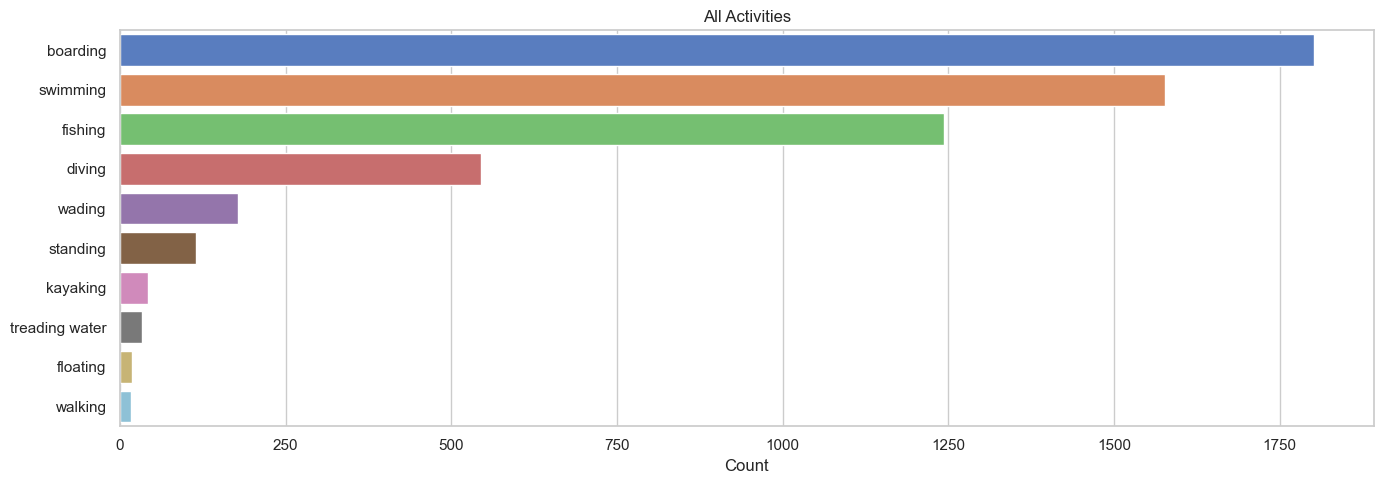

In [40]:
#format figures in line with this example: https://seaborn.pydata.org/examples/part_whole_bars.html
sns.set_theme(style="whitegrid")

plot_data = (
    df3[df3['activity'].isin(['swimming', 'boarding'])]
    ['activity']
    .value_counts()
    .reset_index()
)

plot_data.columns = ['activity', 'count']


all_activities = (
    df3['activity']
    .value_counts()
    .head(10)
    .reset_index()
)

all_activities.columns = ['activity', 'count']


fig, axes = plt.subplots(
    nrows=1,
    ncols=1, #2,
    figsize=(14, 5)
)

# Plot 1
# sns.barplot(
#     data=plot_data,
#     x='count',
#     y='activity',
#     palette='pastel',
#     ax=axes[0]
# )

# axes[0].set_title('Swimming vs Boarding')
# axes[0].set_xlabel('Count')
# axes[0].set_ylabel('')

# Plot 2
sns.barplot(
    data=all_activities,
    x='count',
    y='activity',
    palette='muted',
    ax=axes #[1]
)

# axes[1].set_title('All Activities')
# axes[1].set_xlabel('Count')
# axes[1].set_ylabel('')

axes.set_title('All Activities')
axes.set_xlabel('Count')
axes.set_ylabel('')

plt.tight_layout()
plt.show()

C:\Users\clair\AppData\Local\Temp\ipykernel_12632\2639572697.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


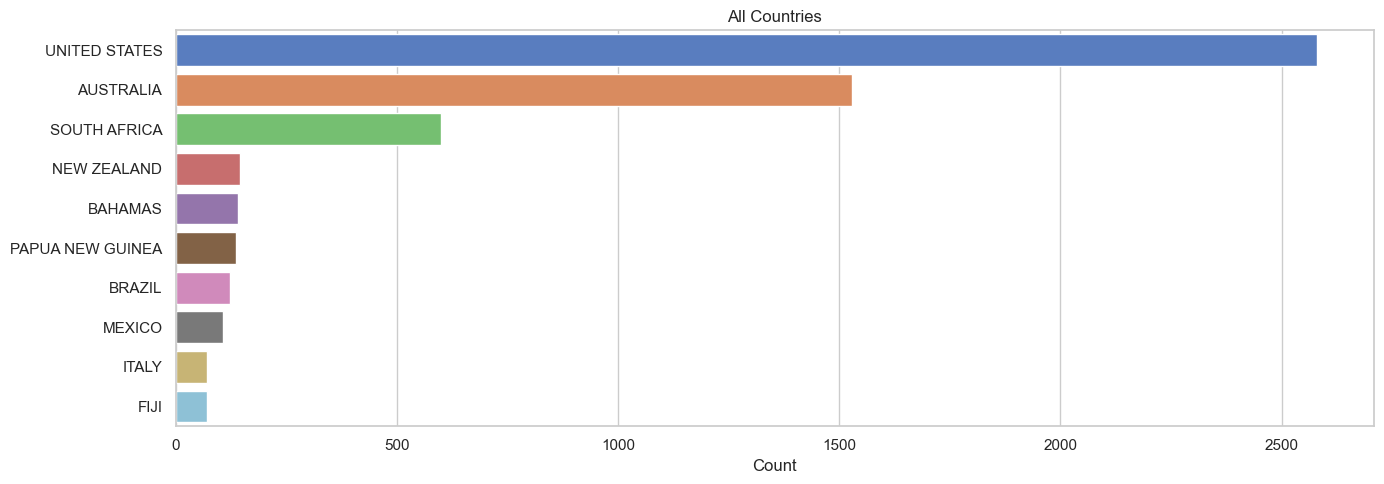

In [41]:
sns.set_theme(style="whitegrid")

all_countries = (
    df3[df3['country'] != 'other']['country']
    .value_counts()
    .head(10)
    .reset_index()
)

all_countries.columns = ['country', 'count']


fig, axes = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(14, 5)
)


sns.barplot(
    data=all_countries,
    x='count',
    y='country',
    palette='muted',
    ax=axes
)

axes.set_title('All Countries')
axes.set_xlabel('Count')
axes.set_ylabel('')

plt.tight_layout()
plt.show()

C:\Users\clair\AppData\Local\Temp\ipykernel_12632\1057167565.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


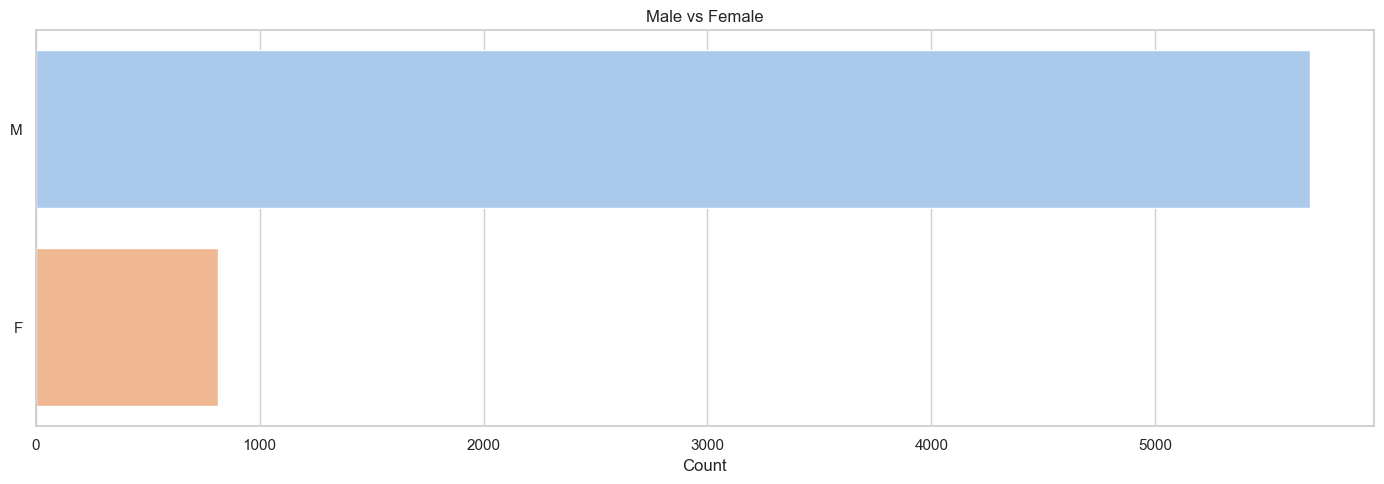

In [42]:
sns.set_theme(style="whitegrid")

plot_data = (
    df3[df3['sex'].isin(['M', 'F'])]
    ['sex']
    .value_counts()
    .reset_index()
)

plot_data.columns = ['sex', 'count']


fig, axes = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(14, 5)
)

# Plot 1
sns.barplot(
    data=plot_data,
    x='count',
    y='sex',
    palette='pastel',
    ax=axes
)

axes.set_title('Male vs Female')
axes.set_xlabel('Count')
axes.set_ylabel('')

plt.tight_layout()
plt.show()

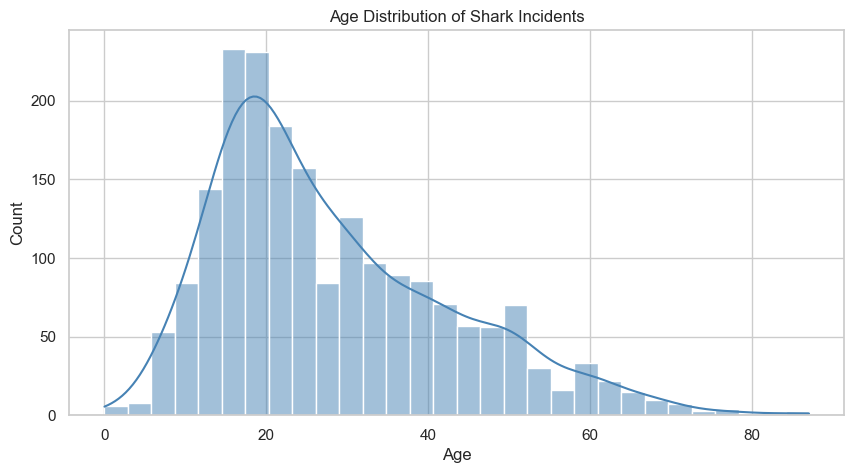

In [43]:
sns.set_theme(style="whitegrid")

df_plot = df3.copy()
df_plot = df_plot[df_plot['age']!='unknown']
df_plot['age'] = pd.to_numeric(df_plot['age'])

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_plot,
    x='age',
    bins=30,
    kde=True,
    color='steelblue'
)

plt.title("Age Distribution of Shark Incidents")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

C:\Users\clair\AppData\Local\Temp\ipykernel_12632\1558473858.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


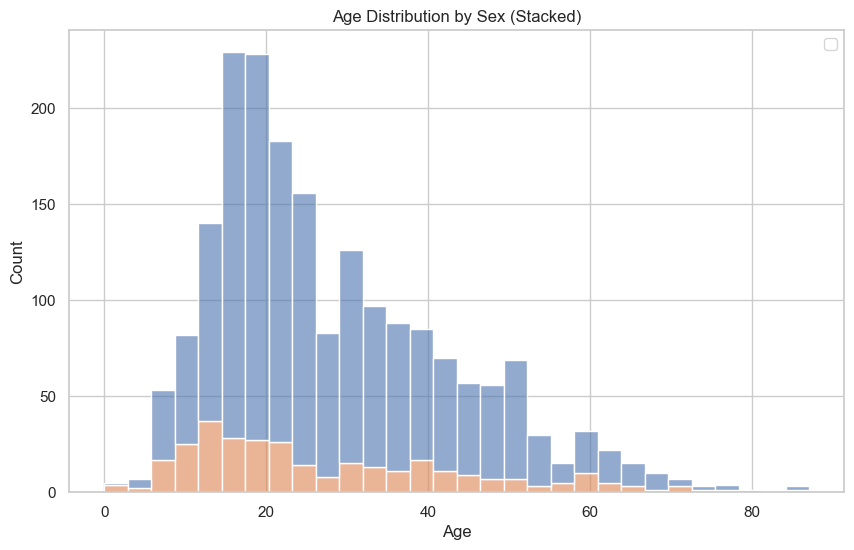

In [44]:
df_plot = df3[['age', 'sex']].copy()

# clean age
df_plot = df_plot[df_plot['age']!='unknown']
df_plot = df_plot[df_plot['sex'].isin(['M','F'])]
df_plot['age'] = pd.to_numeric(df_plot['age'])

# clean sex
df_plot['sex'] = df_plot['sex'].str.lower().str.strip()

# drop missing
df_plot = df_plot.dropna(subset=['age', 'sex'])


plt.figure(figsize=(10, 6))

# stacked histogram
sns.histplot(
    data=df_plot,
    x='age',
    hue='sex',
    multiple='stack',
    bins=30,
    alpha=0.6
)


plt.title("Age Distribution by Sex (Stacked)")
plt.xlabel("Age")
plt.ylabel("Count")

plt.legend()
plt.show()

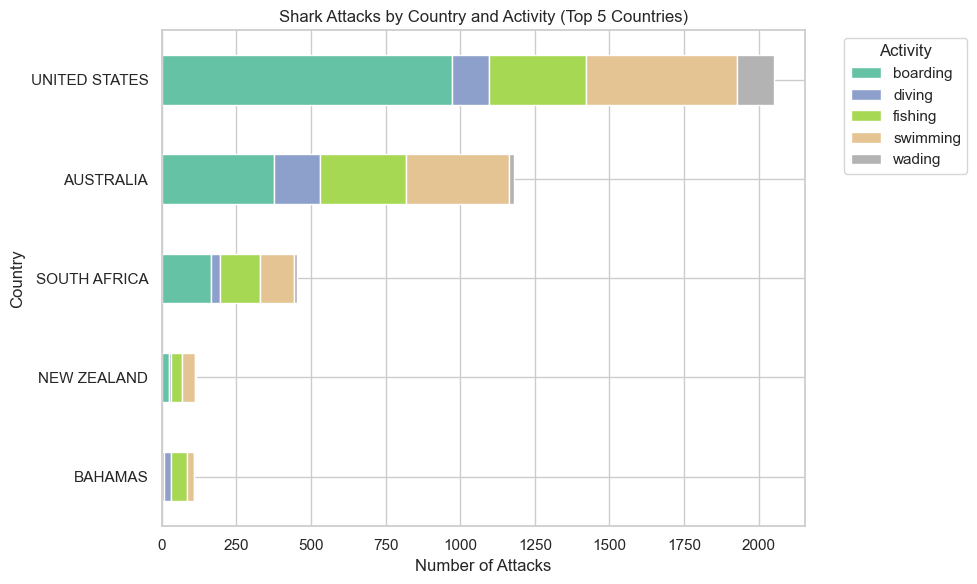

In [45]:
df_plot = df3[['country', 'activity']].copy()

df_plot = df_plot.dropna(subset=['country', 'activity'])

df_plot = df_plot[df_plot['country'] != 'other']
top_countries = df_plot['country'].value_counts().head(5).index
top_activities = df_plot['activity'].value_counts().head(5).index

df_plot = df_plot[
    df_plot['country'].isin(top_countries) &
    df_plot['activity'].isin(top_activities)
]
attack_matrix = pd.crosstab(
    df_plot['country'],
    df_plot['activity']
)

attack_matrix = attack_matrix.loc[
    attack_matrix.sum(axis=1).sort_values().index
]

attack_matrix.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 6),
    colormap='Set2' #'tab20'
)

plt.title("Shark Attacks by Country and Activity (Top 5 Countries)")
plt.xlabel("Number of Attacks")
plt.ylabel("Country")

plt.legend(title="Activity", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()

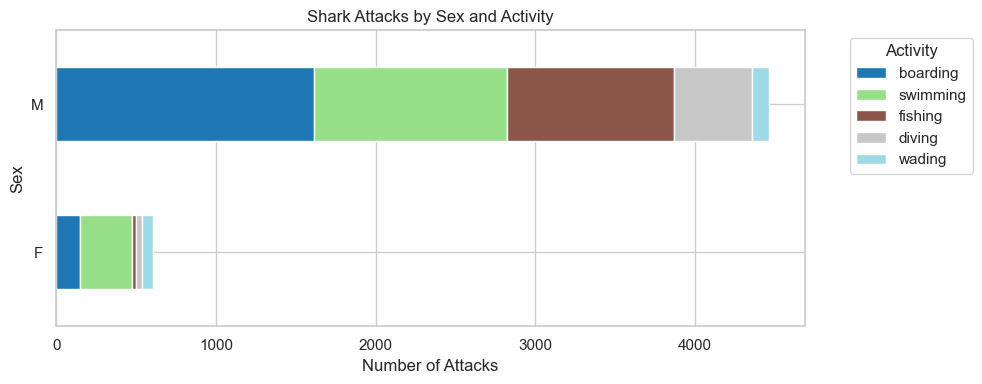

In [46]:
df_plot = df3[['sex', 'activity']].copy()

df_plot = df_plot.dropna(subset=['sex', 'activity'])


df_plot = df_plot[df_plot['sex'].isin(['M', 'F'])]


top_activities = (
    df_plot['activity']
    .value_counts()
    .head(5)
    .index
)

df_plot = df_plot[df_plot['activity'].isin(top_activities)]



sex_activity = pd.crosstab(
    df_plot['sex'],
    df_plot['activity']
)


sex_activity = sex_activity[
    sex_activity.sum(axis=0)
    .sort_values(ascending=False)
    .index
]


sex_activity.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 4),
    colormap='tab20'
)

plt.title("Shark Attacks by Sex and Activity")
plt.xlabel("Number of Attacks")
plt.ylabel("Sex")

plt.legend(
    title="Activity",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()

In [47]:
# Analyze shark attack trends over time

# Create a copy for time analysis
df_time = df3.copy()

# Remove missing dates
df_time = df_time.dropna(subset=['date'])

# Extract year from date
df_time['year'] = df_time['date'].dt.year

# Count shark attacks per year
attacks_per_year = (
    df_time['year']
    .value_counts()
    .sort_index()
)

# Create line plot
plt.figure(figsize=(12, 5))

sns.lineplot(
    x=attacks_per_year.index,
    y=attacks_per_year.values
)

# Customize plot labels and title
plt.title("Shark Attacks Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")

# Display figure
plt.show()

AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
# Analyze seasonal patterns of shark attacks

# Extract month
df_time['month'] = df_time['date'].dt.month_name()

# Define month order
month_order = [
    'January', 'February', 'March',
    'April', 'May', 'June',
    'July', 'August', 'September',
    'October', 'November', 'December'
]

# Count attacks by month
monthly_attacks = (
    df_time['month']
    .value_counts()
    .reindex(month_order)
)

# Create bar plot
plt.figure(figsize=(12, 5))

sns.barplot(
    x=monthly_attacks.index,
    y=monthly_attacks.values,
    color='skyblue'
)

# Customize labels and title
plt.title("Shark Attacks by Month")
plt.xlabel("Month")
plt.ylabel("Number of Attacks")

plt.xticks(rotation=45)

# Display figure
plt.show()

In [48]:
monthly_attacks = (
    df3.dropna(subset=['date'])
    .assign(month=lambda x: x['date'].dt.month_name())
    ['month']
    .value_counts()
)

monthly_attacks

AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
# Analyze changes in shark attack activities over time

# Create decade column
df_time['decade'] = (
    df_time['year'] // 10
) * 10

# Keep top activities
top_activities = (
    df_time['activity']
    .value_counts()
    .head(5)
    .index
)

df_activity = df_time[
    df_time['activity'].isin(top_activities)
]

# Create activity trend table
activity_trend = pd.crosstab(
    df_activity['decade'],
    df_activity['activity']
)

# Plot trends
activity_trend.plot(
    figsize=(12, 6)
)

# Customize labels and title
plt.title("Shark Attack Activities Over Decades")
plt.xlabel("Decade")
plt.ylabel("Number of Attacks")

# Display figure
plt.show()

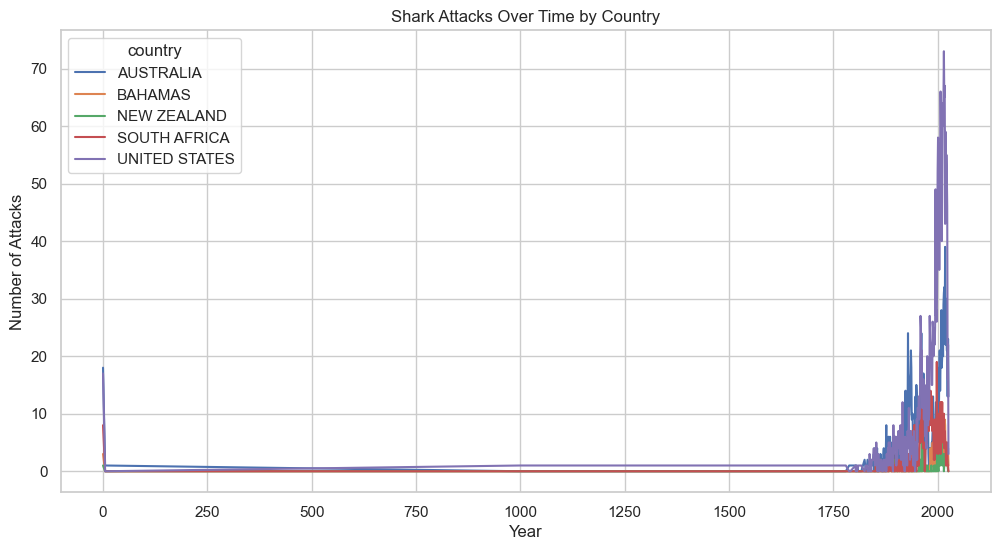

In [49]:
# Compare shark attack trends across countries over time

# Keep top countries
top_countries = (
    df_time[df_time['country'] != 'other']['country']
    .value_counts()
    .head(5)
    .index
)

df_country = df_time[
    df_time['country'].isin(top_countries)
]

# Create country trend table
country_trend = pd.crosstab(
    df_country['year'],
    df_country['country']
)

# Plot trends
country_trend.plot(
    figsize=(12, 6)
)

# Customize labels and title
plt.title("Shark Attacks Over Time by Country")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")

# Display figure
plt.show()

In [52]:
df_time = df3.dropna(subset=['date', 'country']).copy()

df_time['month'] = df_time['date'].dt.month_name()

top_countries = (
    df_time[df_time['country'] != 'other']['country']
    .value_counts()
    .head(5)
    .index
)

df_time = df_time[df_time['country'].isin(top_countries)]

country_month = pd.crosstab(
    df_time['month'],
    df_time['country']
)

month_order = [
    'January', 'February', 'March',
    'April', 'May', 'June',
    'July', 'August', 'September',
    'October', 'November', 'December'
]

country_month = country_month.reindex(month_order)

country_month.plot(figsize=(12,6))

plt.title("Monthly Shark Attacks by Country")
plt.xlabel("Month")
plt.ylabel("Number of Attacks")

plt.show()


AttributeError: Can only use .dt accessor with datetimelike values

In [51]:
country_month

NameError: name 'country_month' is not defined